In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

In [2]:
df = pd.read_csv("../Data/housing.csv")

In [3]:
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


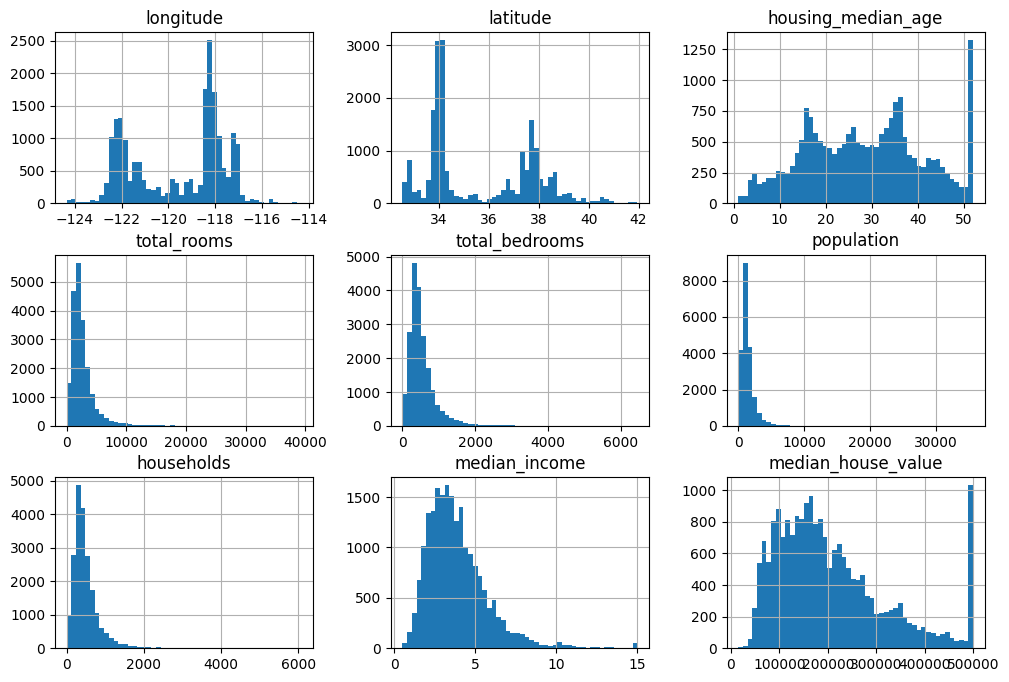

In [7]:
df.hist(bins= 50, figsize=(12,8))
plt.show()

In [8]:
df["income_cat"] = pd.cut(df["median_income"],
                          bins= [0. , 1.5, 3.0, 4.5, 6., np.inf],
                          labels=[1,2,3,4,5])

## 10 Splits

In [9]:
# splitter = StratifiedShuffleSplit(n_splits= 10, test_size= 0.2, random_state= 42)
# strat_splits = []
# for train_index, test_index in splitter.split(df, df["income_cat"]):
#     strat_train_set_n = df.iloc[train_index]
#     strat_test_set_n = df.iloc[test_index]
#     strat_splits.append([strat_train_set_n,strat_test_set_n])

### 10 splits better for model evaluation/cross-validation.
- Reliable performance estimate via averaging 10 stratified folds
- Reduces variance in results
### 1 split better for quick prototyping/final training.
- Faster computation
- Sufficient for large datasets

## 1 Split

In [10]:
strat_train_set, strat_test_set = train_test_split(
    df, test_size = 0.2, stratify = df["income_cat"], random_state=42
)

In [11]:
for set_ in (strat_test_set, strat_train_set):
    set_.drop("income_cat", axis =1, inplace = True)

In [12]:
housing = strat_train_set.copy()

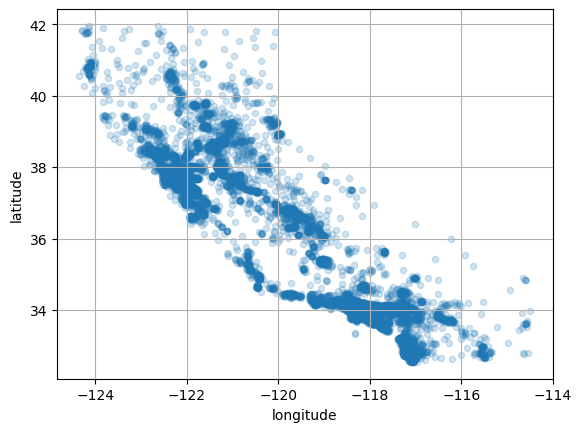

In [13]:
housing.plot(kind = "scatter", x = "longitude", y = "latitude", grid = True, alpha = 0.2)
plt.show()

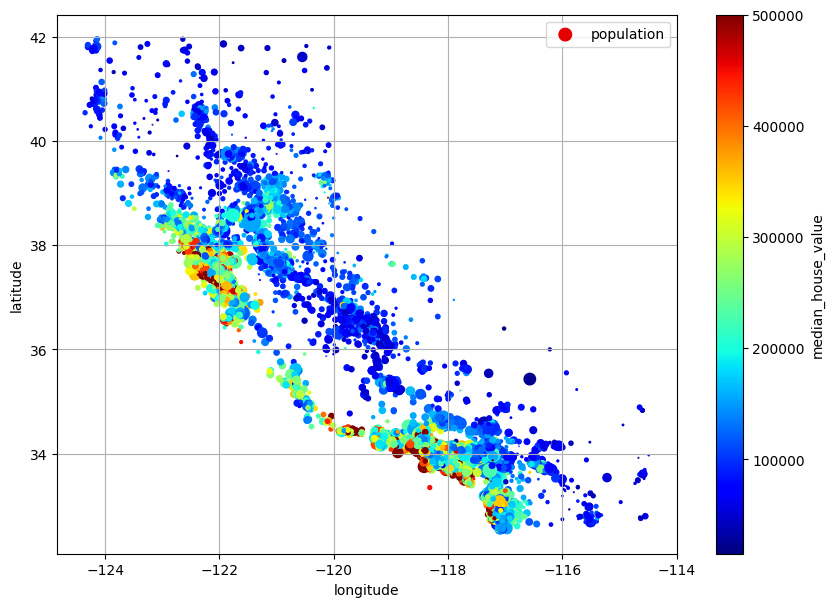

In [14]:
housing.plot(kind = "scatter", x = "longitude", y = "latitude", grid = True,
             s = housing['population'] / 100, label = 'population',
             c = "median_house_value", cmap = "jet", colorbar = True,
             legend = True, sharex = False, figsize = (10,7)
             )
plt.show()

In [15]:
corr_matrix = housing.corr(numeric_only= True) 
corr_matrix["median_house_value"].sort_values

<bound method Series.sort_values of longitude            -0.050859
latitude             -0.139584
housing_median_age    0.102175
total_rooms           0.137455
total_bedrooms        0.054635
population           -0.020153
households            0.071426
median_income         0.688380
median_house_value    1.000000
Name: median_house_value, dtype: float64>